## 1.Import Necessary Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

## 2.Import Dataset

In [2]:
college_data = pd.read_csv("college_list.csv")
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9
...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6


## 3.Data Understanding

In [3]:
college_data.shape

(500, 6)

In [4]:
college_data.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64

In [5]:
college_data["College_Name"]

0       Indian Institute of Technology Madras - Campus 1
1      National Institute of Technology Trichy - Camp...
2                     Anna University Chennai - Campus 1
3                   PSG College of Technology - Campus 1
4          Coimbatore Institute of Technology - Campus 1
                             ...                        
495       Thiagarajar College of Engineering - Campus 17
496    Bannari Amman Institute of Technology - Campus 17
497    Sri Krishna College of Engineering and Technol...
498               Sona College of Technology - Campus 17
499          Karpagam College of Engineering - Campus 17
Name: College_Name, Length: 500, dtype: object

In [6]:
college_data["College_Name"].unique()

array(['Indian Institute of Technology Madras - Campus 1',
       'National Institute of Technology Trichy - Campus 1',
       'Anna University Chennai - Campus 1',
       'PSG College of Technology - Campus 1',
       'Coimbatore Institute of Technology - Campus 1',
       'Government College of Technology Coimbatore - Campus 1',
       'SSN College of Engineering - Campus 1',
       'SRM Institute of Science and Technology - Campus 1',
       'VIT Vellore - Campus 1', 'SASTRA University - Campus 1',
       'Sri Sairam Engineering College - Campus 1',
       'Velammal Engineering College - Campus 1',
       'Rajalakshmi Engineering College - Campus 1',
       'St Josephs College of Engineering - Campus 1',
       'Kumaraguru College of Technology - Campus 1',
       'Thiagarajar College of Engineering - Campus 1',
       'Bannari Amman Institute of Technology - Campus 1',
       'Sri Krishna College of Engineering and Technology - Campus 1',
       'Sona College of Technology - Campus

In [7]:
college_data.describe()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600
std,6.683283,63928.678815,17.193465,2.917991,2.00486
min,8.000000,30404.000000,40.000000,2.000000,3.00000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000
max,29.000000,249930.000000,99.000000,11.990000,9.00000


## 4.Data Preppuration

### 4.1 Delete Unwanted Data

In [8]:
x = college_data.drop(labels="College_Name",axis=1)

### 4.1 Applay Data Trensformation Tecniques

In [9]:
sd_scalare_model = StandardScaler()
x_scaled = sd_scalare_model.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled)
x_scaled

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


## 5.Model Building

### Step 1 :Let's Check Dindogram

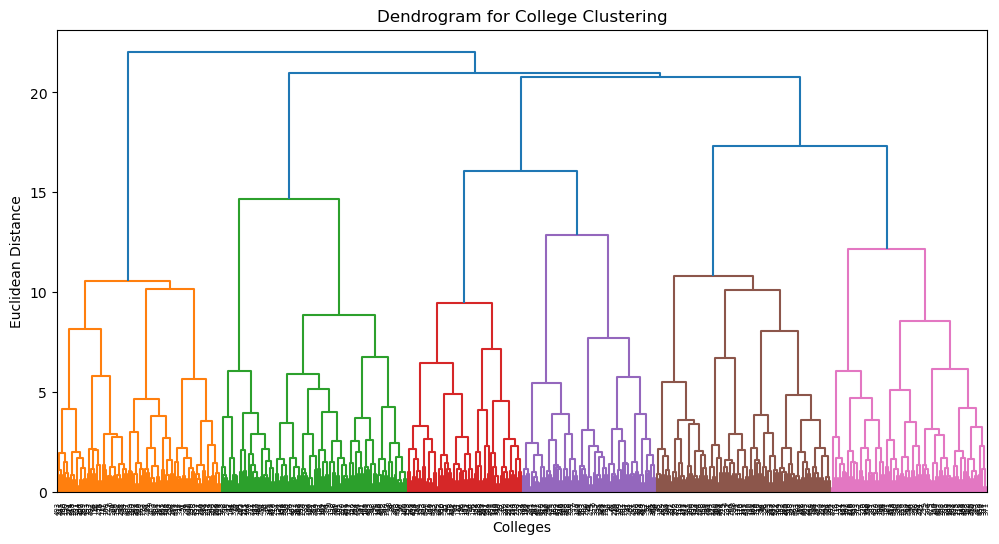

In [10]:
plt.figure(figsize = (12,6))
dendrogram = sch.dendrogram(sch.linkage(x_scaled,method='ward'))
plt.title("Dendrogram for College Clustering")
plt.xlabel("Colleges")
plt.ylabel("Euclidean Distance")
plt.show()

### For understanding purpose take only 20 colleges to visualize 

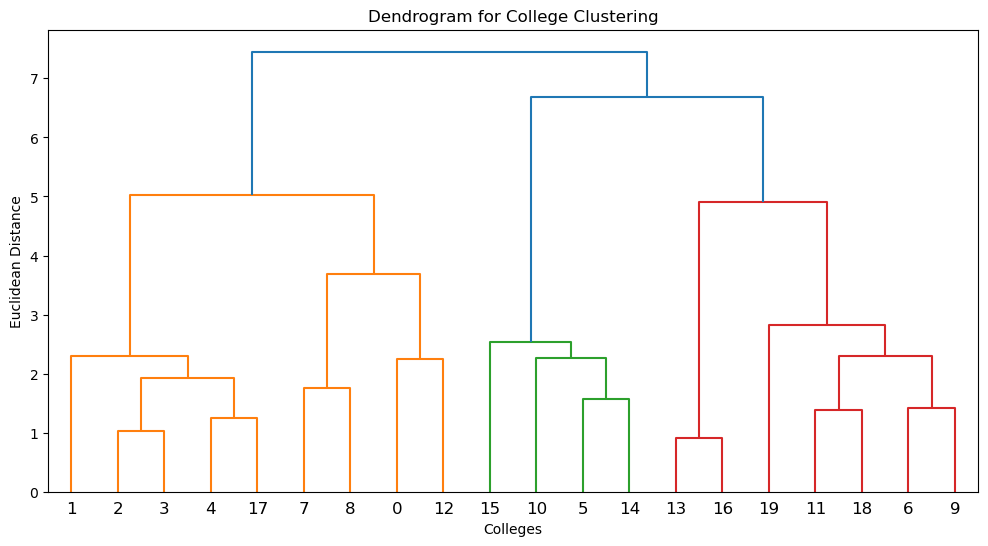

In [11]:
plt.figure(figsize=(12,6))
top_20 = x_scaled.head(20)
dendrogram = sch.dendrogram(sch.linkage(top_20,method='ward'))
plt.title("Dendrogram for College Clustering")
plt.xlabel("Colleges")
plt.ylabel("Euclidean Distance")
plt.show()

### Step 2: Apply Agglomerative Clustering(Based on dendrogram, assume 3 clusters)    

In [12]:
horisondel_cluster_model = AgglomerativeClustering( n_clusters=3,metric='euclidean',linkage='ward',)
horisondel_cluster_model

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [15]:
cluster = horisondel_cluster_model.fit_predict(x_scaled)
cluster

array([2, 0, 0, 0, 0, 0, 1, 0, 2, 1, 0, 1, 0, 2, 0, 0, 2, 0, 1, 1, 0, 2,
       2, 0, 1, 0, 0, 0, 0, 0, 0, 2, 1, 2, 2, 0, 1, 0, 2, 1, 0, 1, 0, 0,
       2, 0, 1, 0, 0, 0, 0, 1, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 2,
       0, 2, 2, 2, 0, 0, 0, 0, 0, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 1, 1, 2,
       0, 2, 1, 0, 0, 0, 0, 1, 2, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 2, 2, 2, 2, 0, 0, 2, 0, 1, 0, 0, 2, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 1, 0, 0, 0, 0,
       2, 0, 0, 1, 1, 2, 0, 2, 1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 2, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 2, 2,
       0, 0, 2, 2, 1, 0, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 1, 1, 0, 2, 0, 0,
       1, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 2, 0, 0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 1, 0,

### Clustering is DONE here. Let's put this back to the original Dataset for further Data Mining Operations

### ===========================================================================================================================

## LEVEL 2: Attach Clusters to Dataset

### 1. Attach Clusters to Dataset

In [19]:
college_data["college_level"] = cluster
college_data.head()

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0


### 2. Data Understanding - Analyze Clusters

In [20]:
college_data

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0
...,...,...,...,...,...,...,...
495,Thiagarajar College of Engineering - Campus 17,17,106323,56,9.33,5,0
496,Bannari Amman Institute of Technology - Campus 17,12,39111,76,3.62,7,0
497,Sri Krishna College of Engineering and Technol...,16,199182,64,3.88,3,1
498,Sona College of Technology - Campus 17,10,46389,77,9.31,6,0


In [21]:
college_data.groupby(by="college_level").agg("mean")

TypeError: agg function failed [how->mean,dtype->object]

### We did some Mistake here. What is that?

## We had that categorical column and we were not able to take mean for the complete Dataset

In [22]:
college_data.head()

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,0


In [24]:
x # this is only contain the numerical value

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


In [25]:
x["college_level"] = cluster
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level
0,14,113042,59,9.20,8,2
1,27,115999,67,3.07,7,0
2,22,47955,50,3.40,9,0
3,18,67841,43,4.64,8,0
4,15,100640,54,4.66,9,0
...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0
496,12,39111,76,3.62,7,0
497,16,199182,64,3.88,3,1
498,10,46389,77,9.31,6,0


In [28]:
x.groupby(by="college_level").agg("mean").round()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
college_level,,,,,
0,20.0,121853.0,67.0,7.0,7.0
1,17.0,156795.0,86.0,6.0,4.0
2,12.0,175656.0,60.0,8.0,6.0


In [31]:
x.groupby(by="college_level").agg(["mean","max","min"]).round()

Student_Faculty_Ratio         Annual_Fees_INR                 \
                               mean max min            mean     max    min   
college_level                                                                
0                              20.0  29   8        121853.0  249536  30404   
1                              17.0  29   8        156795.0  248803  39337   
2                              12.0  20   8        175656.0  249930  49065   

              Placement_Percentage         Average_Package_LPA             \
                              mean max min                mean   max  min   
college_level                                                               
0                             67.0  99  40                 7.0  12.0  2.0   
1                             86.0  99  64                 6.0  12.0  2.0   
2                             60.0  99  40                 8.0  12.0  2.0   

              Infrastructure_Score          
                              mean max min  
college_level                               
0                              7.0   9   3  
1                              4.0   9   3  
2                              6.0   9   3

In [35]:
cluster_name = {1:"Best Colleges",
                2:"Mid_Leval_Colleges",
                0:"Emerning / Lower-Leval Colleges"}
x["Category"] = x["college_level"].map(cluster_name)

In [36]:
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level,Category
0,14,113042,59,9.20,8,2,Mid_Leval_Colleges
1,27,115999,67,3.07,7,0,Emerning / Lower-Leval Colleges
2,22,47955,50,3.40,9,0,Emerning / Lower-Leval Colleges
3,18,67841,43,4.64,8,0,Emerning / Lower-Leval Colleges
4,15,100640,54,4.66,9,0,Emerning / Lower-Leval Colleges
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0,Emerning / Lower-Leval Colleges
496,12,39111,76,3.62,7,0,Emerning / Lower-Leval Colleges
497,16,199182,64,3.88,3,1,Best Colleges
498,10,46389,77,9.31,6,0,Emerning / Lower-Leval Colleges


### ===================================================================================================================================

## LEVEL 3: Now it's time to Transition to Supervised Learning

In [37]:
x

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,college_level,Category
0,14,113042,59,9.20,8,2,Mid_Leval_Colleges
1,27,115999,67,3.07,7,0,Emerning / Lower-Leval Colleges
2,22,47955,50,3.40,9,0,Emerning / Lower-Leval Colleges
3,18,67841,43,4.64,8,0,Emerning / Lower-Leval Colleges
4,15,100640,54,4.66,9,0,Emerning / Lower-Leval Colleges
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0,Emerning / Lower-Leval Colleges
496,12,39111,76,3.62,7,0,Emerning / Lower-Leval Colleges
497,16,199182,64,3.88,3,1,Best Colleges
498,10,46389,77,9.31,6,0,Emerning / Lower-Leval Colleges


In [45]:
#Import Necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

#Data Preppuration
X = x.drop(labels=["college_level","Category"],axis=1)
y = x.college_level

#Model Building
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=46,shuffle=True,stratify=y)

model = RandomForestClassifier(max_depth=10)

#Model Training
model.fit(x_train,y_train)

#Model Testing
model.predict(x_test)

#Model Evaluation
print(model.score(x_test,y_test))
print(model.score(x_train,y_train))

0.93
1.0


### Take the model out to add in the backend

In [53]:
import pickle

In [56]:
pickle.dump(model,open("college_category_model.pkl","wb"))

# THE END!!!